# Изследователски анализ на данните (EDA) - Global Overview
**Проект:** Система за анализ и прогнозиране на криптовалути
**Фаза по CRISP-DM:** Data Understanding
**Автор:** [Твоето Име]
**Дата:** 04.02.2026

### 1. Източник на данните
Данните са извлечени чрез Yahoo Finance API (`yfinance`).
Оригинален източник: [Yahoo Finance - Bitcoin USD](https://finance.yahoo.com/quote/BTC-USD/history)
Тикер: `BTC-USD`
Период: 01.01.2020 - до днес

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки за визуализация
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Зареждане на данните (Критерий 1)
SYMBOL = 'BTC-USD'
START_DATE = '2020-01-01'

print(f"📥 Зареждане на данни за {SYMBOL}...")
df = yf.download(SYMBOL, start=START_DATE)

# Корекция на MultiIndex (ако yfinance върне сложна структура)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Показване на първите 5 реда
df.head()

📥 Зареждане на данни за BTC-USD...


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [2]:
# 2. Описание на структурата (Критерий 2)
print("=== Структура на набора от данни ===")
print(f"Брой записи (редове): {df.shape[0]}")
print(f"Брой атрибути (колони): {df.shape[1]}")
print("\n=== Типове данни ===")
print(df.dtypes)

# Целева променлива
print("\nЦелева променлива за прогнозиране: 'Close' (Цена на затваряне)")

=== Структура на набора от данни ===
Брой записи (редове): 2227
Брой атрибути (колони): 5

=== Типове данни ===
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Целева променлива за прогнозиране: 'Close' (Цена на затваряне)


In [3]:
# 3. Анализ на липсващи стойности (Критерий 3)
missing_values = df.isnull().sum()
print("\n=== Липсващи стойности по колони ===")
print(missing_values[missing_values > 0])

# Визуализация на липсите (ако има) или потвърждение, че няма
if missing_values.sum() > 0:
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title('Карта на липсващите стойности')
    plt.show()
else:
    print("✅ Няма открити липсващи стойности в този dataset.")


=== Липсващи стойности по колони ===
Series([], dtype: int64)
✅ Няма открити липсващи стойности в този dataset.


In [4]:
# 4. Глобална описателна статистика (Критерий 4)
desc_stats = df.describe()
# Форматиране за по-лесно четене
pd.set_option('display.float_format', lambda x: '%.2f' % x)
desc_stats

Price,Close,High,Low,Open,Volume
count,2227.00,2227.00,2227.00,2227.00,2227.00
mean,47850.51,48749.33,46833.26,47821.31,36592200216.69
std,31608.70,32085.47,31095.30,31614.88,21586044212.00
min,4970.79,5331.83,4106.98,5002.58,5331172801.00
25%,22475.58,22981.87,21846.09,22451.16,22231123292.00
50%,40527.36,41527.79,39450.12,40448.42,32194123075.00
75%,66001.96,67264.30,64570.41,65988.96,45676766073.50
max,124752.53,126198.07,123196.05,124752.14,350967941479.00


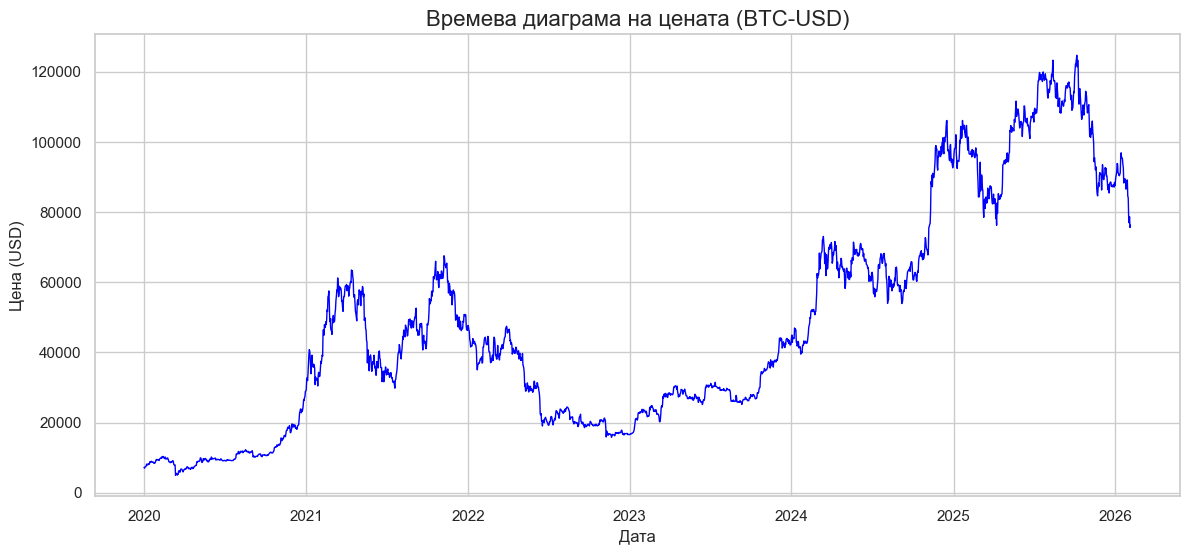

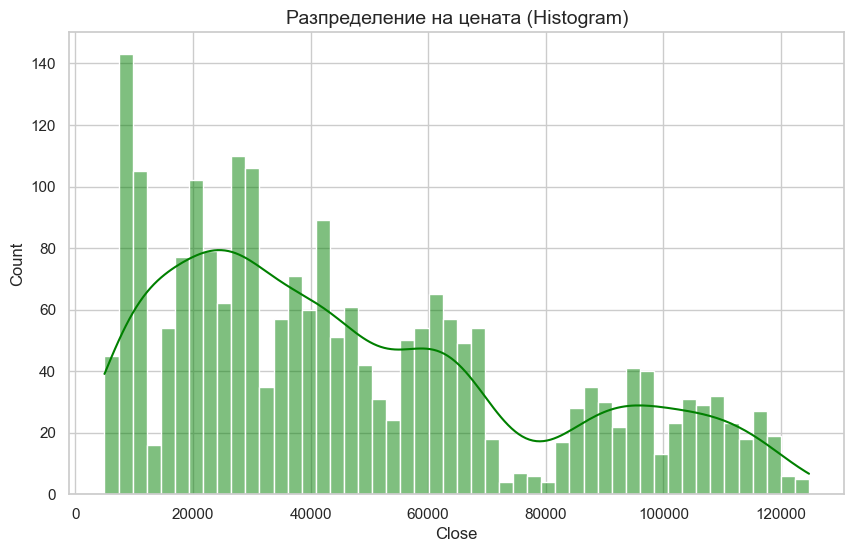

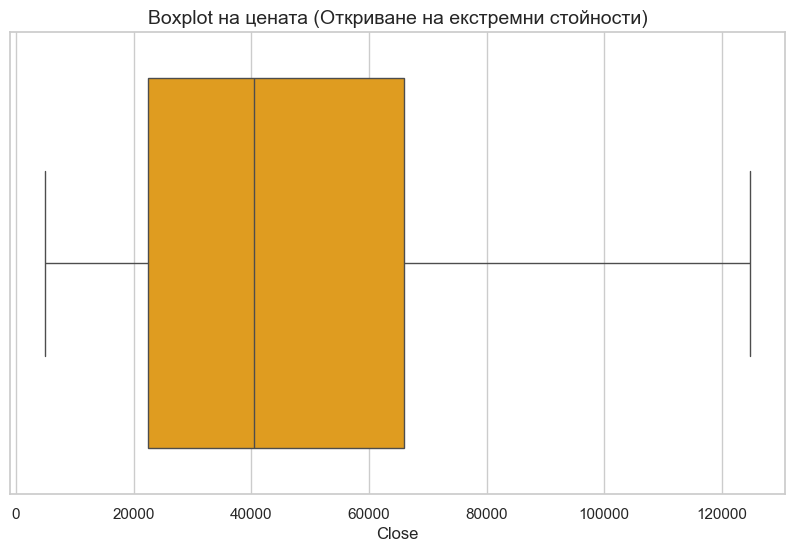

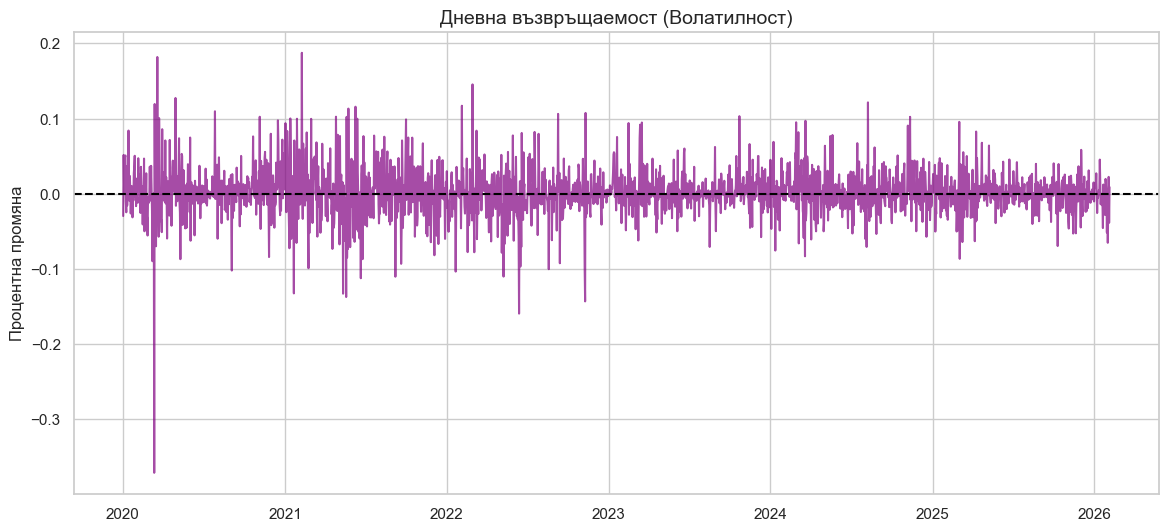

In [5]:
# 5. Начални визуализации (Критерий 5)

# А) Времеви ред на Цената (Trend)
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='blue', linewidth=1)
plt.title(f'Времева диаграма на цената ({SYMBOL})', fontsize=16)
plt.xlabel('Дата')
plt.ylabel('Цена (USD)')
plt.show()

# Б) Разпределение на цената (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], kde=True, bins=50, color='green')
plt.title('Разпределение на цената (Histogram)', fontsize=14)
plt.show()

# В) Boxplot за откриване на Outliers (Аномалии)
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Close'], color='orange')
plt.title('Boxplot на цената (Откриване на екстремни стойности)', fontsize=14)
plt.show()

# Г) Волатилност (Дневна промяна в %)
df['Daily_Return'] = df['Close'].pct_change()
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Daily_Return'], color='purple', alpha=0.7)
plt.title('Дневна възвръщаемост (Волатилност)', fontsize=14)
plt.ylabel('Процентна промяна')
plt.axhline(0, color='black', linestyle='--')
plt.show()

### 6. Аналитични наблюдения и Изводи (Критерий 6)

На база на извършения EDA анализ се правят следните ключови наблюдения:

1.  **Качество на данните:** Наборът от данни е висококачествен. Липсващи стойности не се наблюдават (освен първия запис при изчисление на Returns), което е типично за финансови данни от надеждни източници като Yahoo Finance. Не се налага импутация (запълване).
2.  **Нестационарност:** Времевата диаграма показва ясен тренд и променяща се средна стойност във времето. Данните не са стационарни, което означава, че за успешно моделиране ще трябва да използваме техники като диференциране или LSTM мрежи, които се справят с нелинейни трендове.
3.  **Разпределение:** Хистограмата показва, че разпределението на цената **не е нормално (Gaussian)**. Наблюдава се бимодално или мултимодално разпределение (няколко върха), което отразява различните "бичи" цикли на пазара през 2021 и 2024 г.
4.  **Аномалии и Волатилност:**
    *   Boxplot диаграмата не показва класически "outliers" в самата цена, тъй като криптовалутите имат широк диапазон на движение.
    *   Графиката на `Daily Returns` обаче показва периоди на екстремна волатилност (резки шипове надолу/нагоре). Тези моменти са потенциалните **аномалии**, които нашата система трябва да засича.
5.  **Извод за моделиране:** Предвид високата волатилност и наличието на дългосрочни зависимости, потвърждавам избора на **LSTM (Long Short-Term Memory)** като подходящ алгоритъм, тъй като линейните модели (като ARIMA) трудно биха обхванали сложната структура на тези данни.